In [15]:
import pandas as pd
import numpy as np
import warnings
from Univariate import Univariate
warnings.filterwarnings("ignore")

dataset = pd.read_csv("Placement.csv")

quan, qual = Univariate.quanQual(dataset)

In [16]:
#Before replacing outliers
descriptive = pd.DataFrame(index=['Mean','Median','Mode','Q1:25%','Q2:50%','Q3:75%','99%','Q4:100%',"IQR","1.5RULE",
                                  "LesserOutlier","GreaterOutlier","Min","Max","hasOutlier_Lower?", "hasOutlier_Higher?",
                                 "Skewness","Kurtosis"], columns=quan)

lesser_outliers = []
greater_outliers = []

for column in quan:
    descriptive[column]['Mean'] = dataset[column].mean()
    descriptive[column]['Median'] = dataset[column].median()
    descriptive[column]['Mode'] = dataset[column].mode()[0]
    descriptive[column]['Q1:25%'] = dataset.describe()[column]['25%']
    descriptive[column]['Q2:50%'] = dataset.describe()[column]['50%']
    descriptive[column]['Q3:75%'] = dataset.describe()[column]['75%']
    descriptive[column]['99%'] = np.percentile(dataset[column],99)
    descriptive[column]['Q4:100%'] = dataset.describe()[column]['max']
    descriptive[column]['IQR'] = descriptive[column]['Q3:75%'] - descriptive[column]['Q1:25%']
    descriptive[column]['1.5RULE'] = 1.5*descriptive[column]['IQR']
    descriptive[column]['LesserOutlier'] = descriptive[column]['Q1:25%'] - descriptive[column]['1.5RULE']
    descriptive[column]['GreaterOutlier'] = descriptive[column]['Q3:75%'] + descriptive[column]['1.5RULE']
    descriptive[column]['Min'] = dataset[column].min()
    descriptive[column]['Max'] = dataset[column].max()
    if descriptive[column]['Min'] < descriptive[column]['LesserOutlier']:
        descriptive[column]['hasOutlier_Lower?'] = "YES"
        lesser_outliers.append(column)
    else:
        descriptive[column]['hasOutlier_Lower?'] = "NO"
        
    if descriptive[column]['Max'] > descriptive[column]['GreaterOutlier']:
        descriptive[column]['hasOutlier_Higher?'] = "YES"
        greater_outliers.append(column)
    else:
        descriptive[column]['hasOutlier_Higher?'] = "NO"

    descriptive[column]['Skewness'] = dataset[column].skew()
    descriptive[column]['Kurtosis'] = dataset[column].kurtosis()

descriptive

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
Mean,108.0,67.303395,66.333163,66.370186,72.100558,62.278186,288655.405405
Median,108.0,67.0,65.0,66.0,71.0,62.0,265000.0
Mode,1,62.0,63.0,65.0,60.0,56.7,300000.0
Q1:25%,54.5,60.6,60.9,61.0,60.0,57.945,240000.0
Q2:50%,108.0,67.0,65.0,66.0,71.0,62.0,265000.0
Q3:75%,161.5,75.7,73.0,72.0,83.5,66.255,300000.0
99%,212.86,87.0,91.86,83.86,97.0,76.1142,NaN
Q4:100%,215.0,89.4,97.7,91.0,98.0,77.89,940000.0
IQR,107.0,15.1,12.1,11.0,23.5,8.31,60000.0
1.5RULE,160.5,22.65,18.15,16.5,35.25,12.465,90000.0


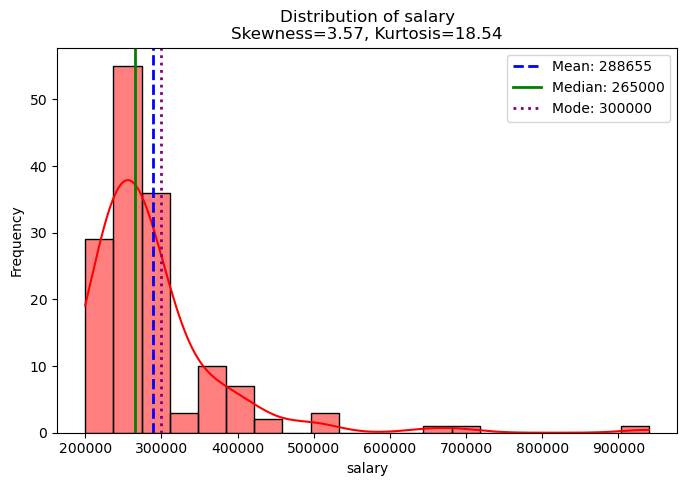

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(dataset["salary"], kde=True, bins=20, color='red')

mean_val = descriptive["salary"]['Mean']
median_val = descriptive["salary"]['Median']
mode_val = descriptive["salary"]['Mode']

plt.axvline(mean_val, color='blue', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.0f}')
plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.0f}')
plt.axvline(mode_val, color='purple', linestyle=':', linewidth=2, label=f'Mode: {mode_val:.0f}')

plt.title(f'Distribution of salary\nSkewness={descriptive["salary"]['Skewness']:.2f}, Kurtosis={descriptive["salary"]['Kurtosis']:.2f}')
plt.xlabel("salary")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [18]:
#replacing the outliers
for column in lesser_outliers:
    dataset[column][dataset[column] < descriptive[column]['LesserOutlier']] = descriptive[column]['LesserOutlier']

for column in greater_outliers:
    dataset[column][dataset[column] > descriptive[column]['GreaterOutlier']] = descriptive[column]['GreaterOutlier']

In [19]:
#Analysis after replacing outliers
descriptiveNew = pd.DataFrame(index=['Mean','Median','Mode','Q1:25%','Q2:50%','Q3:75%','99%','Q4:100%',"IQR","1.5RULE",
                                  "LesserOutlier","GreaterOutlier","Min","Max","hasOutlier_Lower?", "hasOutlier_Higher?",
                                    "Skewness","Kurtosis"], columns=quan)

lesser_outliers = []
greater_outliers = []

for column in quan:
    descriptiveNew[column]['Mean'] = dataset[column].mean()
    descriptiveNew[column]['Median'] = dataset[column].median()
    descriptiveNew[column]['Mode'] = dataset[column].mode()[0]
    descriptiveNew[column]['Q1:25%'] = dataset.describe()[column]['25%']
    descriptiveNew[column]['Q2:50%'] = dataset.describe()[column]['50%']
    descriptiveNew[column]['Q3:75%'] = dataset.describe()[column]['75%']
    descriptiveNew[column]['99%'] = np.percentile(dataset[column],99)
    descriptiveNew[column]['Q4:100%'] = dataset.describe()[column]['max']
    descriptiveNew[column]['IQR'] = descriptiveNew[column]['Q3:75%'] - descriptiveNew[column]['Q1:25%']
    descriptiveNew[column]['1.5RULE'] = 1.5*descriptiveNew[column]['IQR']
    descriptiveNew[column]['LesserOutlier'] = descriptiveNew[column]['Q1:25%'] - descriptiveNew[column]['1.5RULE']
    descriptiveNew[column]['GreaterOutlier'] = descriptiveNew[column]['Q3:75%'] + descriptiveNew[column]['1.5RULE']
    descriptiveNew[column]['Min'] = dataset[column].min()
    descriptiveNew[column]['Max'] = dataset[column].max()
    if descriptiveNew[column]['Min'] < descriptiveNew[column]['LesserOutlier']:
        descriptiveNew[column]['hasOutlier_Lower?'] = "YES"
        lesser_outliers.append(column)
    else:
        descriptiveNew[column]['hasOutlier_Lower?'] = "NO"
    if descriptiveNew[column]['Max'] > descriptiveNew[column]['GreaterOutlier']:
        descriptiveNew[column]['hasOutlier_Higher?'] = "YES"
        greater_outliers.append(column)
    else:
        descriptiveNew[column]['hasOutlier_Higher?'] = "NO"

    descriptiveNew[column]['Skewness'] = dataset[column].skew()
    descriptiveNew[column]['Kurtosis'] = dataset[column].kurtosis()

descriptiveNew

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
Mean,108.0,67.303395,66.334744,66.358558,72.100558,62.278186,277648.648649
Median,108.0,67.0,65.0,66.0,71.0,62.0,265000.0
Mode,1,62.0,63.0,65.0,60.0,56.7,300000.0
Q1:25%,54.5,60.6,60.9,61.0,60.0,57.945,240000.0
Q2:50%,108.0,67.0,65.0,66.0,71.0,62.0,265000.0
Q3:75%,161.5,75.7,73.0,72.0,83.5,66.255,300000.0
99%,212.86,87.0,91.129,83.86,97.0,76.1142,NaN
Q4:100%,215.0,89.4,91.15,88.5,98.0,77.89,390000.0
IQR,107.0,15.1,12.1,11.0,23.5,8.31,60000.0
1.5RULE,160.5,22.65,18.15,16.5,35.25,12.465,90000.0


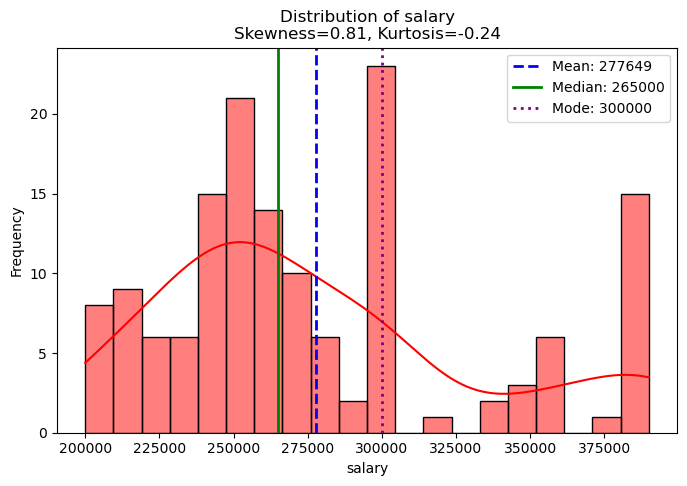

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(dataset["salary"], kde=True, bins=20, color='red')

mean_val = descriptiveNew["salary"]['Mean']
median_val = descriptiveNew["salary"]['Median']
mode_val = descriptiveNew["salary"]['Mode']

plt.axvline(mean_val, color='blue', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.0f}')
plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.0f}')
plt.axvline(mode_val, color='purple', linestyle=':', linewidth=2, label=f'Mode: {mode_val:.0f}')

plt.title(f'Distribution of salary\nSkewness={descriptiveNew["salary"]['Skewness']:.2f}, Kurtosis={descriptiveNew["salary"]['Kurtosis']:.2f}')
plt.xlabel("salary")
plt.ylabel("Frequency")
plt.legend()
plt.show()

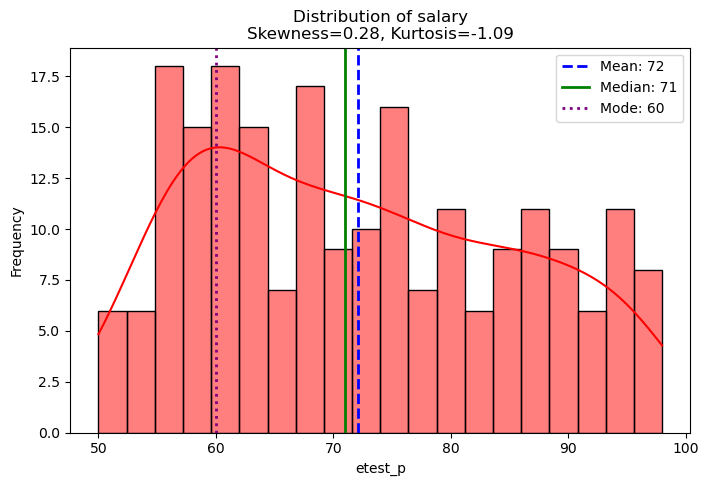

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(dataset["etest_p"], kde=True, bins=20, color='red')

mean_val = descriptiveNew["etest_p"]['Mean']
median_val = descriptiveNew["etest_p"]['Median']
mode_val = descriptiveNew["etest_p"]['Mode']

plt.axvline(mean_val, color='blue', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.0f}')
plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.0f}')
plt.axvline(mode_val, color='purple', linestyle=':', linewidth=2, label=f'Mode: {mode_val:.0f}')

plt.title(f'Distribution of salary\nSkewness={descriptiveNew["etest_p"]['Skewness']:.2f}, Kurtosis={descriptiveNew["etest_p"]['Kurtosis']:.2f}')
plt.xlabel("etest_p")
plt.ylabel("Frequency")
plt.legend()
plt.show()

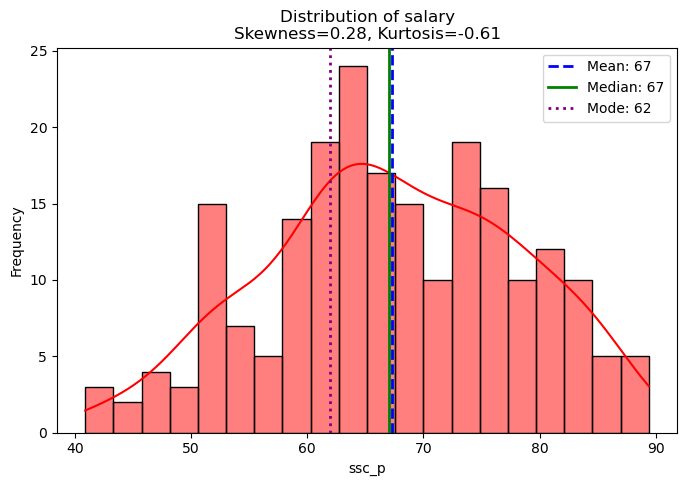

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(dataset["ssc_p"], kde=True, bins=20, color='red')

mean_val = descriptiveNew["ssc_p"]['Mean']
median_val = descriptiveNew["ssc_p"]['Median']
mode_val = descriptiveNew["ssc_p"]['Mode']

plt.axvline(mean_val, color='blue', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.0f}')
plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.0f}')
plt.axvline(mode_val, color='purple', linestyle=':', linewidth=2, label=f'Mode: {mode_val:.0f}')

plt.title(f'Distribution of salary\nSkewness={descriptiveNew["etest_p"]['Skewness']:.2f}, Kurtosis={descriptiveNew["ssc_p"]['Kurtosis']:.2f}')
plt.xlabel("ssc_p")
plt.ylabel("Frequency")
plt.legend()
plt.show()